In [1]:
pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, avg, sum as spark_sum, min, max, stddev,
    desc, asc, when, countDistinct
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("✅ Imports OK")

✅ Imports OK


In [3]:
# إعدادات الرسم
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Style set")

✅ Style set


In [4]:
spark = SparkSession.builder \
    .appName("UNSW-NB15-EDA") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

print(f"✅ Spark version: {spark.version}")

✅ Spark version: 3.1.2


In [5]:
PARQUET_PATH = "file:///tmp/unsw_cleaned.parquet"
OUTPUT_DIR = "/workspace/data/curated/eda"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = spark.read.parquet(PARQUET_PATH)
df.cache()

print(f"✅ عدد السجلات: {df.count():,}")
print(f"✅ عدد الأعمدة: {len(df.columns)}")
print(f"📁 Parquet: {PARQUET_PATH}")
print(f"📁 Output: {OUTPUT_DIR}")


✅ عدد السجلات: 2,540,047
✅ عدد الأعمدة: 49
📁 Parquet: file:///tmp/unsw_cleaned.parquet
📁 Output: /workspace/data/curated/eda


In [6]:
# نظرة عامة
print("📊 نظرة عامة:")
print(f"  - عدد السجلات: {df.count():,}")
print(f"  - عدد الأعمدة: {len(df.columns)}")
print(f"\n📋 Schema:")
df.printSchema()

print("\n📋 أول 5 سطور:")
df.show(5, truncate=False)

📊 نظرة عامة:
  - عدد السجلات: 2,540,047
  - عدد الأعمدة: 49

📋 Schema:
root
 |-- srcip: string (nullable = true)
 |-- sport: integer (nullable = true)
 |-- dstip: string (nullable = true)
 |-- dsport: integer (nullable = true)
 |-- proto: string (nullable = true)
 |-- state: string (nullable = true)
 |-- dur: double (nullable = true)
 |-- sbytes: integer (nullable = true)
 |-- dbytes: integer (nullable = true)
 |-- sttl: integer (nullable = true)
 |-- dttl: integer (nullable = true)
 |-- sloss: integer (nullable = true)
 |-- dloss: integer (nullable = true)
 |-- service: string (nullable = true)
 |-- Sload: double (nullable = true)
 |-- Dload: double (nullable = true)
 |-- Spkts: integer (nullable = true)
 |-- Dpkts: integer (nullable = true)
 |-- swin: integer (nullable = true)
 |-- dwin: integer (nullable = true)
 |-- stcpb: integer (nullable = true)
 |-- dtcpb: integer (nullable = true)
 |-- smeansz: integer (nullable = true)
 |-- dmeansz: integer (nullable = true)
 |-- trans_depth:

📊 Label Distribution:
    Label    count
0  Attack   321283
1  Normal  2218764


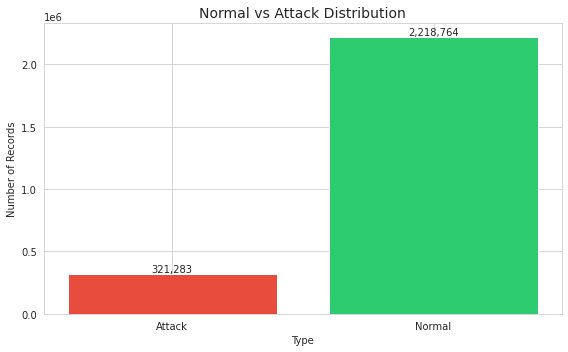

✅ Saved: 01_label_distribution.png


In [7]:
# =========================================================
# Label Distribution (Normal vs Attack)
# =========================================================

label_dist = df.groupBy("Label").count().toPandas()
label_dist["Label"] = label_dist["Label"].map({0: "Normal", 1: "Attack"})

print("📊 Label Distribution:")
print(label_dist)

plt.figure(figsize=(8, 5))
plt.bar(label_dist["Label"], label_dist["count"], color=["#e74c3c", "#2ecc71"])
plt.title("Normal vs Attack Distribution", fontsize=14)
plt.ylabel("Number of Records")
plt.xlabel("Type")
for i, v in enumerate(label_dist["count"]):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_label_distribution.png", dpi=100)
plt.show()
print("✅ Saved: 01_label_distribution.png")

📊 Attack Category Distribution:
        attack_cat    count
0             None  2218764
1          Generic   215481
2         Exploits    44525
3          Fuzzers    24246
4              DoS    16353
5   Reconnaissance    13987
6         Analysis     2677
7         Backdoor     1795
8        Shellcode     1511
9        Backdoors      534
10           Worms      174


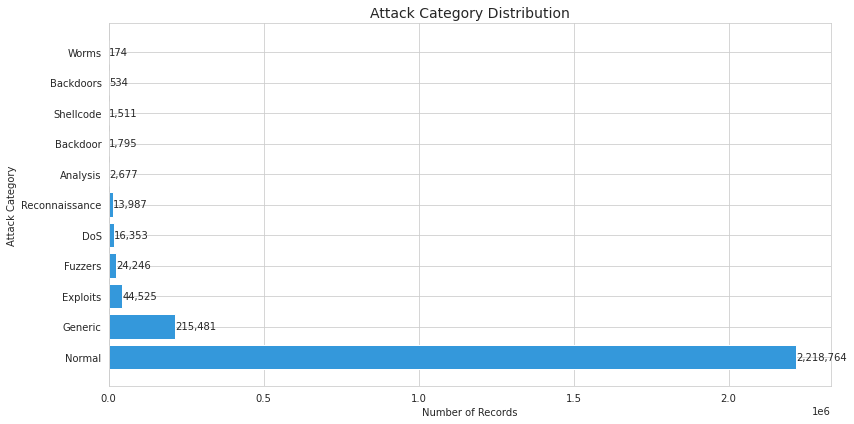

✅ Saved: 02_attack_cat.png


In [8]:
# =========================================================
# Attack Category Distribution
# =========================================================

attack_dist = df.groupBy("attack_cat").count() \
    .orderBy(desc("count")) \
    .toPandas()

print("📊 Attack Category Distribution:")
print(attack_dist)

plt.figure(figsize=(12, 6))
plt.barh(
    attack_dist["attack_cat"].fillna("Normal"),
    attack_dist["count"],
    color="#3498db"
)
plt.title("Attack Category Distribution", fontsize=14)
plt.xlabel("Number of Records")
plt.ylabel("Attack Category")
for i, v in enumerate(attack_dist["count"]):
    plt.text(v, i, f"{v:,}", va="center")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_attack_cat.png", dpi=100)
plt.show()
print("✅ Saved: 02_attack_cat.png")

📊 Top 10 Protocols:
  proto    count
0   tcp  1495074
1   udp   990435
2  unas    16202
3   arp    10064
4  ospf     7798
5  sctp     1525
6  icmp      524
7   any      411
8   gre      324
9  rsvp      274


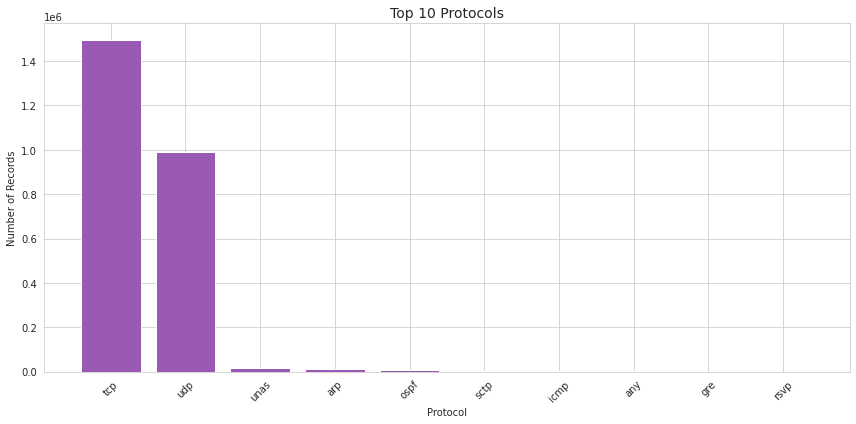

✅ Saved: 03_proto.png


In [9]:
# =========================================================
# Top 10 Protocols
# =========================================================

proto_dist = df.groupBy("proto").count() \
    .orderBy(desc("count")) \
    .limit(10) \
    .toPandas()

print("📊 Top 10 Protocols:")
print(proto_dist)

plt.figure(figsize=(12, 6))
plt.bar(proto_dist["proto"], proto_dist["count"], color="#9b59b6")
plt.title("Top 10 Protocols", fontsize=14)
plt.xlabel("Protocol")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_proto.png", dpi=100)
plt.show()
print("✅ Saved: 03_proto.png")

📊 Top 10 Services:
    service    count
0      None  1246397
1       dns   781668
2      http   206273
3  ftp-data   125783
4      smtp    81645
5       ftp    49090
6       ssh    47160
7      pop3     1533
8      dhcp      172
9       ssl      142


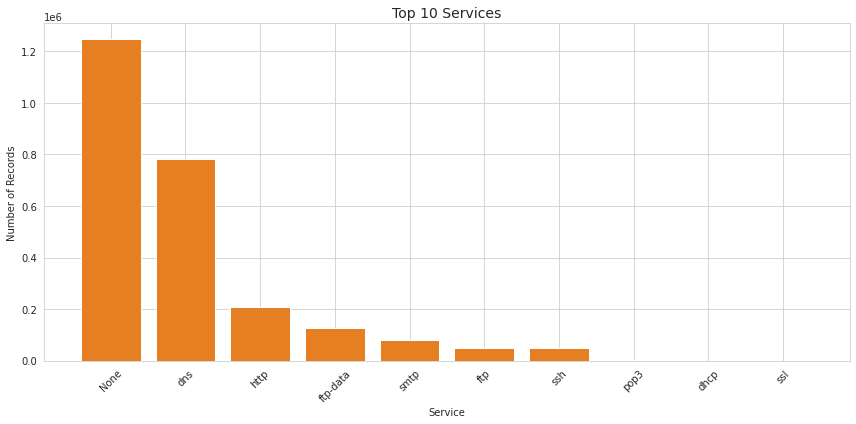

✅ Saved: 04_service.png


In [10]:
# =========================================================
# Top 10 Services
# =========================================================

service_dist = df.groupBy("service").count() \
    .orderBy(desc("count")) \
    .limit(10) \
    .toPandas()

print("📊 Top 10 Services:")
print(service_dist)

plt.figure(figsize=(12, 6))
plt.bar(
    service_dist["service"].fillna("None"),
    service_dist["count"],
    color="#e67e22"
)
plt.title("Top 10 Services", fontsize=14)
plt.xlabel("Service")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_service.png", dpi=100)
plt.show()
print("✅ Saved: 04_service.png")

📊 State Distribution:
   state    count
0    FIN  1478689
1    CON   560588
2    INT   490471
3    REQ     9043
4    RST      528
5    ECO      337
6    CLO      161
7    URH      108
8    ACC       43
9    PAR       30
10   ECR        9
11   TST        9
12   URN        8
13    no        8
14   MAS        8
15   TXD        7


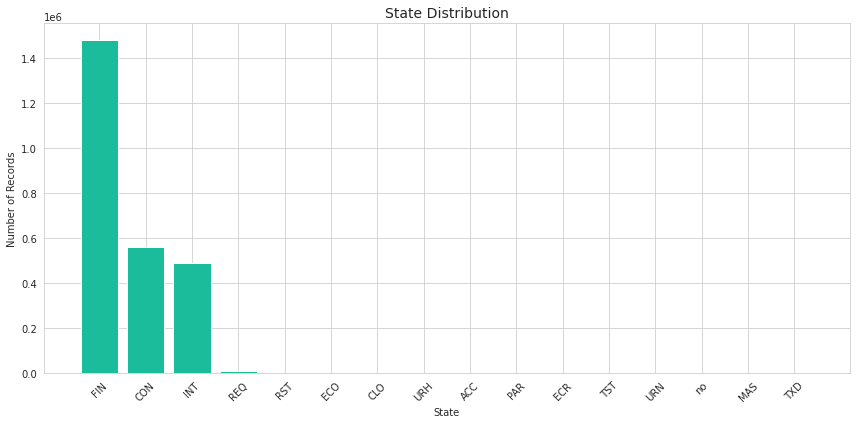

✅ Saved: 05_state.png


In [11]:
# =========================================================
# State Distribution
# =========================================================

state_dist = df.groupBy("state").count() \
    .orderBy(desc("count")) \
    .toPandas()

print("📊 State Distribution:")
print(state_dist)

plt.figure(figsize=(12, 6))
plt.bar(state_dist["state"], state_dist["count"], color="#1abc9c")
plt.title("State Distribution", fontsize=14)
plt.xlabel("State")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_state.png", dpi=100)
plt.show()
print("✅ Saved: 05_state.png")

In [13]:
# =========================================================
# Descriptive Statistics
# =========================================================

# الأعمدة الرقمية
numeric_cols = [
    "dur", "sbytes", "dbytes", "Sload", "Dload",
    "Spkts", "Dpkts", "smeansz", "dmeansz",
    "Sjit", "Djit", "Sintpkt", "Dintpkt",
    "tcprtt", "synack", "ackdat"
]

# إحصاءات
stats = df.select(numeric_cols).describe().toPandas()

print("📊 Descriptive Statistics:")
print(stats.to_string())

# احفظ
stats.to_csv(f"{OUTPUT_DIR}/06_statistics.csv", index=False)
print(f"\n✅ Saved: 06_statistics.csv")

📊 Descriptive Statistics:
  summary                 dur              sbytes              dbytes                Sload               Dload              Spkts               Dpkts             smeansz             dmeansz                Sjit                Djit             Sintpkt            Dintpkt                tcprtt                 synack                ackdat
0   count             2540047             2540047             2540047              2540047             2540047            2540047             2540047             2540047             2540047             2540047             2540047             2540047            2540047               2540047                2540047               2540047
1    mean  0.6587915950777115  4339.6000640933025  36427.593727990075   3.69564475089112E7  2450861.2162569175  33.28884347415619    42.7266408849915    124.253610661535   276.6719100079644  1589.0366782790618   730.0754645252138  193.32248825501208  78.82476440597704  0.006180474734521993  0.00328759

⏳ سحب عينة 10%...
✅ العينة: 254,145 سطر


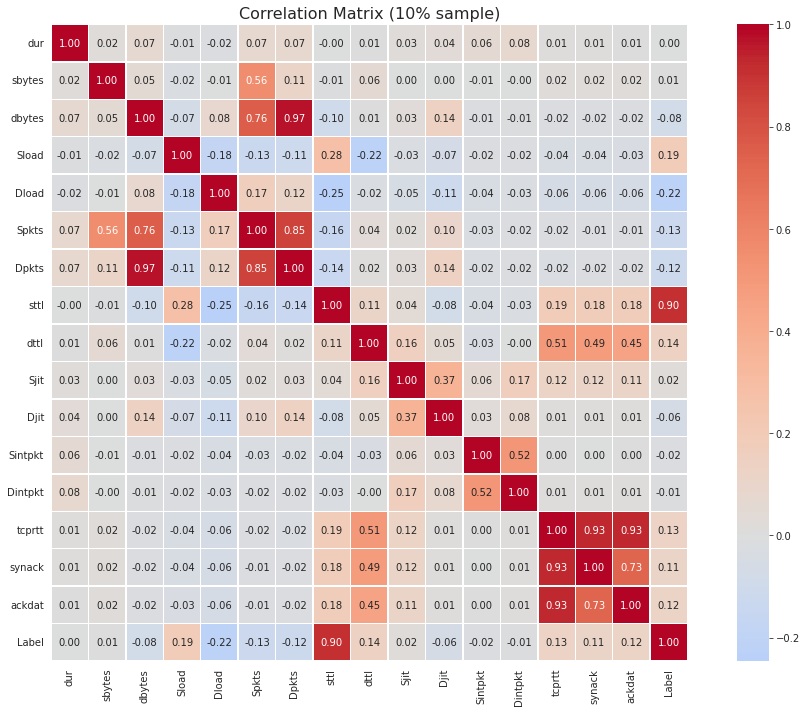

✅ Saved: 07_correlation.png
✅ Saved: 07_correlation.csv


In [14]:
# =========================================================
# Correlation Matrix (10% Sample)
# =========================================================

numeric_cols_short = [
    "dur", "sbytes", "dbytes", "Sload", "Dload",
    "Spkts", "Dpkts", "sttl", "dttl",
    "Sjit", "Djit", "Sintpkt", "Dintpkt",
    "tcprtt", "synack", "ackdat", "Label"
]

# عينة 10% فقط (250K سطر)
sample_df = df.select(numeric_cols_short).sample(fraction=0.1, seed=42)
print(f"⏳ سحب عينة 10%...")

corr_data = sample_df.toPandas()
print(f"✅ العينة: {len(corr_data):,} سطر")

corr_matrix = corr_data.corr()

# رسم
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix (10% sample)", fontsize=16)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_correlation.png", dpi=100)
plt.show()
print("✅ Saved: 07_correlation.png")

corr_matrix.to_csv(f"{OUTPUT_DIR}/07_correlation.csv")
print("✅ Saved: 07_correlation.csv")

📊 Records: 5


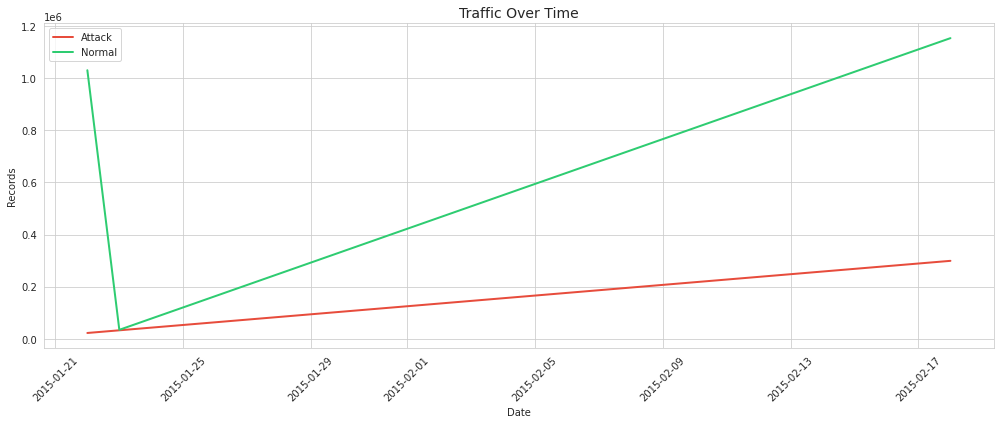

✅ Saved: 08_time_series.png


In [15]:
from pyspark.sql.functions import from_unixtime, to_date

df_time = df.withColumn("date", to_date(from_unixtime(col("Stime"))))

time_dist = df_time.groupBy("date", "Label").count() \
    .orderBy("date").toPandas()

print(f"📊 Records: {len(time_dist)}")

fig, ax = plt.subplots(figsize=(14, 6))
for label in time_dist["Label"].unique():
    data = time_dist[time_dist["Label"] == label]
    name = "Normal" if label == 0 else "Attack"
    color = "#2ecc71" if label == 0 else "#e74c3c"
    ax.plot(data["date"], data["count"], label=name, color=color, linewidth=2)

ax.set_title("Traffic Over Time", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Records")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/08_time_series.png", dpi=100)
plt.show()
print("✅ Saved: 08_time_series.png")

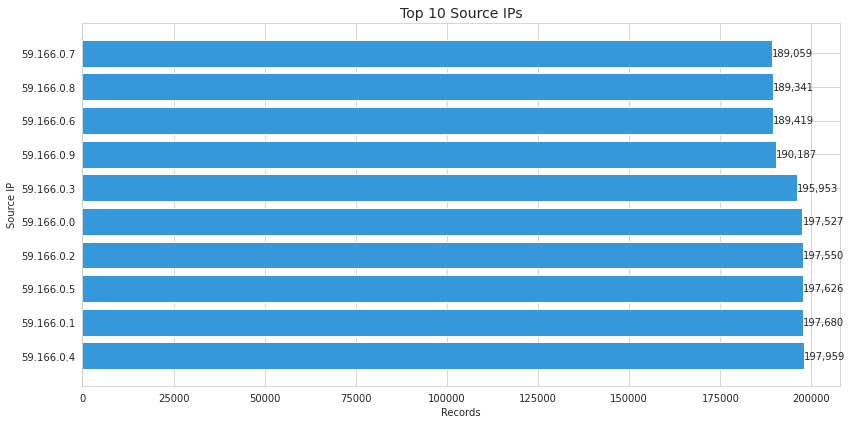

✅ Saved: 09_top_src_ip.png


In [16]:
srcip_dist = df.groupBy("srcip").count() \
    .orderBy(desc("count")).limit(10).toPandas()

plt.figure(figsize=(12, 6))
plt.barh(srcip_dist["srcip"], srcip_dist["count"], color="#3498db")
plt.title("Top 10 Source IPs", fontsize=14)
plt.xlabel("Records")
plt.ylabel("Source IP")
for i, v in enumerate(srcip_dist["count"]):
    plt.text(v, i, f"{v:,}", va="center")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/09_top_src_ip.png", dpi=100)
plt.show()
print("✅ Saved: 09_top_src_ip.png")

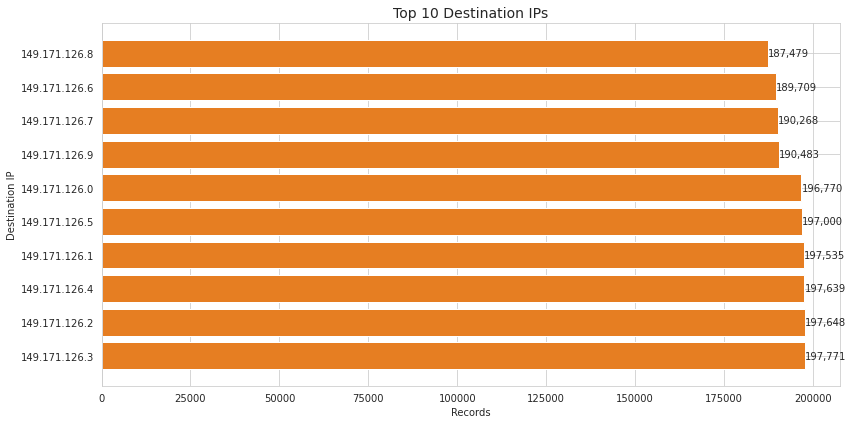

✅ Saved: 10_top_dst_ip.png


In [17]:
dstip_dist = df.groupBy("dstip").count() \
    .orderBy(desc("count")).limit(10).toPandas()

plt.figure(figsize=(12, 6))
plt.barh(dstip_dist["dstip"], dstip_dist["count"], color="#e67e22")
plt.title("Top 10 Destination IPs", fontsize=14)
plt.xlabel("Records")
plt.ylabel("Destination IP")
for i, v in enumerate(dstip_dist["count"]):
    plt.text(v, i, f"{v:,}", va="center")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/10_top_dst_ip.png", dpi=100)
plt.show()
print("✅ Saved: 10_top_dst_ip.png")

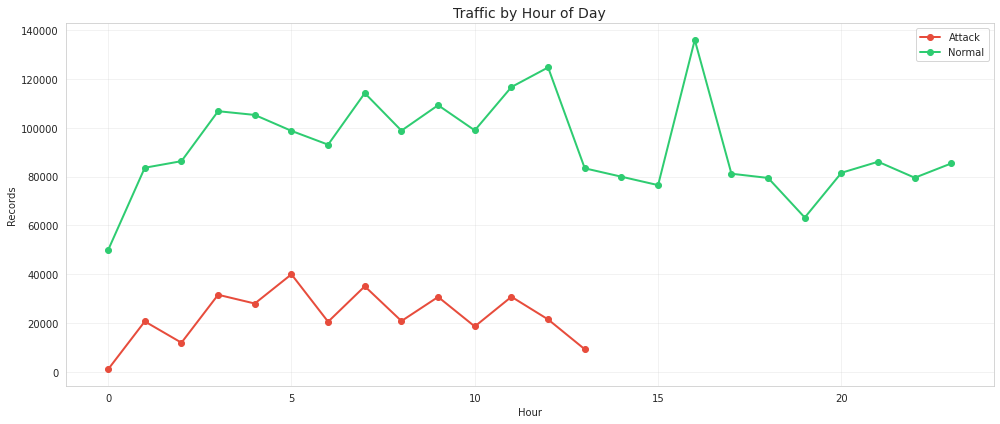

✅ Saved: 11_hour_traffic.png


In [18]:
from pyspark.sql.functions import from_unixtime, to_date, dayofweek, hour

df_time = df.withColumn("datetime", from_unixtime(col("Stime"))) \
    .withColumn("date", to_date(col("datetime"))) \
    .withColumn("day_of_week", dayofweek(col("datetime"))) \
    .withColumn("hour", hour(col("datetime")))

# حسب ساعة اليوم
hour_dist = df_time.groupBy("hour", "Label").count() \
    .orderBy("hour").toPandas()

fig, ax = plt.subplots(figsize=(14, 6))
for label in hour_dist["Label"].unique():
    data = hour_dist[hour_dist["Label"] == label]
    name = "Normal" if label == 0 else "Attack"
    color = "#2ecc71" if label == 0 else "#e74c3c"
    ax.plot(data["hour"], data["count"], label=name, color=color, marker="o", linewidth=2)

ax.set_title("Traffic by Hour of Day", fontsize=14)
ax.set_xlabel("Hour")
ax.set_ylabel("Records")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/11_hour_traffic.png", dpi=100)
plt.show()
print("✅ Saved: 11_hour_traffic.png")

📊 Attack Ratio per Protocol:
          Normal    Attack      Total  Attack_Ratio
proto                                              
tcp    1436890.0   58184.0  1495074.0          3.89
udp     766685.0  223750.0   990435.0         22.59
unas         0.0   16202.0    16202.0        100.00
arp      10064.0       0.0    10064.0          0.00
ospf      4520.0    3278.0     7798.0         42.04
sctp         0.0    1525.0     1525.0        100.00
icmp       524.0       0.0      524.0          0.00
any          0.0     411.0      411.0        100.00
gre          0.0     324.0      324.0        100.00
rsvp         0.0     274.0      274.0        100.00


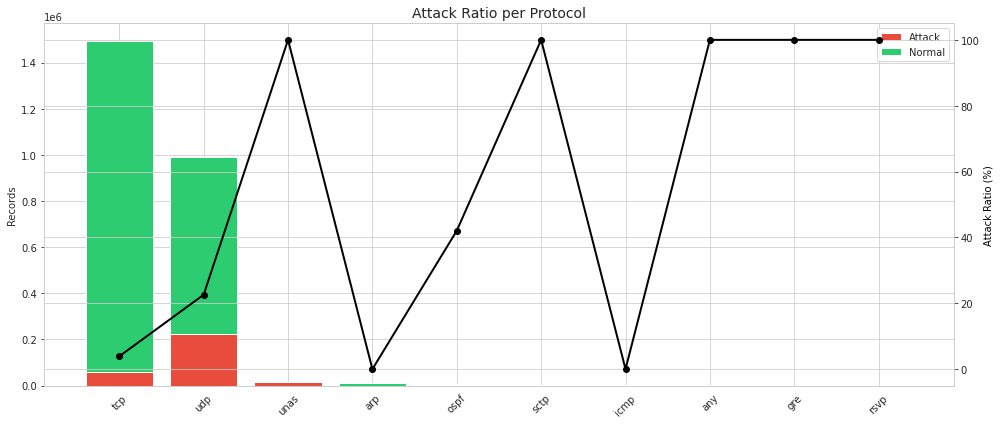

✅ Saved: 12_proto_attack.png


In [19]:
# نسبة الهجمات لكل بروتوكول
proto_attack = df.groupBy("proto", "Label").count() \
    .toPandas()

# Pivot
proto_pivot = proto_attack.pivot(index="proto", columns="Label", values="count").fillna(0)
proto_pivot.columns = ["Normal", "Attack"]
proto_pivot["Total"] = proto_pivot["Normal"] + proto_pivot["Attack"]
proto_pivot["Attack_Ratio"] = proto_pivot["Attack"] / proto_pivot["Total"] * 100
proto_pivot = proto_pivot.sort_values("Total", ascending=False).head(10)

print("📊 Attack Ratio per Protocol:")
print(proto_pivot.round(2))

# رسم
fig, ax1 = plt.subplots(figsize=(14, 6))
x = range(len(proto_pivot))
ax1.bar(x, proto_pivot["Attack"], color="#e74c3c", label="Attack")
ax1.bar(x, proto_pivot["Normal"], bottom=proto_pivot["Attack"], color="#2ecc71", label="Normal")
ax1.set_xticks(x)
ax1.set_xticklabels(proto_pivot.index, rotation=45)
ax1.set_ylabel("Records")
ax1.set_title("Attack Ratio per Protocol", fontsize=14)
ax1.legend()

ax2 = ax1.twinx()
ax2.plot(x, proto_pivot["Attack_Ratio"], color="black", marker="o", linewidth=2)
ax2.set_ylabel("Attack Ratio (%)", color="black")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/12_proto_attack.png", dpi=100)
plt.show()
print("✅ Saved: 12_proto_attack.png")

📊 Attack Ratio per Service:
             Normal    Attack      Total  Attack_Ratio
service                                               
NaN       1166520.0   79877.0  1246397.0          6.41
dns        571037.0  210631.0   781668.0         26.95
http       187426.0   18847.0   206273.0          9.14
ftp-data   123893.0    1890.0   125783.0          1.50
smtp        76656.0    4989.0    81645.0          6.11
ftp         46075.0    3015.0    49090.0          6.14
ssh         47141.0      19.0    47160.0          0.04
pop3            4.0    1529.0     1533.0         99.74
dhcp            0.0     172.0      172.0        100.00
ssl             0.0     142.0      142.0        100.00


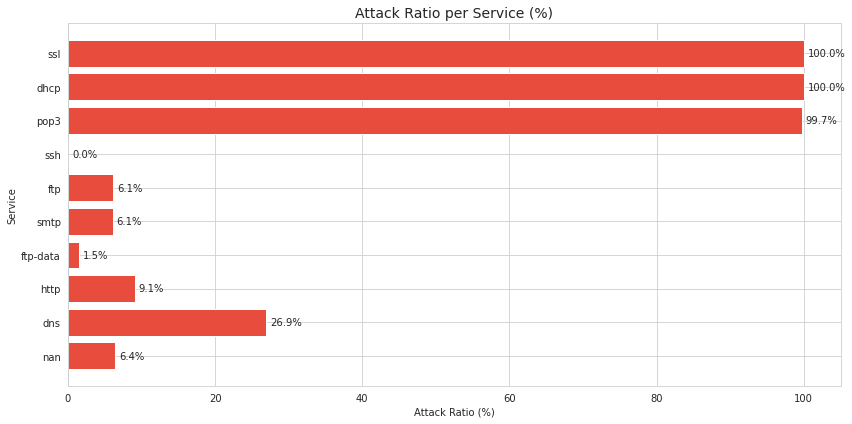

✅ Saved: 13_service_attack.png


In [21]:
# =========================================================
# Attack Ratio per Service
# =========================================================

service_attack = df.groupBy("service", "Label").count().toPandas()
service_pivot = service_attack.pivot(index="service", columns="Label", values="count").fillna(0)
service_pivot.columns = ["Normal", "Attack"]
service_pivot["Total"] = service_pivot["Normal"] + service_pivot["Attack"]
service_pivot["Attack_Ratio"] = service_pivot["Attack"] / service_pivot["Total"] * 100
service_pivot = service_pivot.sort_values("Total", ascending=False).head(10)

print("📊 Attack Ratio per Service:")
print(service_pivot.round(2))

# الحل: استخدم range بدل index
fig, ax = plt.subplots(figsize=(12, 6))
y_pos = range(len(service_pivot))
ax.barh(y_pos, service_pivot["Attack_Ratio"].values, color="#e74c3c")
ax.set_yticks(y_pos)
ax.set_yticklabels([str(x) for x in service_pivot.index])
ax.set_title("Attack Ratio per Service (%)", fontsize=14)
ax.set_xlabel("Attack Ratio (%)")
ax.set_ylabel("Service")

# إضافة القيم
for i, v in enumerate(service_pivot["Attack_Ratio"].values):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/13_service_attack.png", dpi=100)
plt.show()
print("✅ Saved: 13_service_attack.png")

📊 Average Traffic Volume:
   Label   avg_sbytes    avg_dbytes  avg_Spkts  avg_Dpkts   avg_dur    Type
0      1  5848.631674   4446.658613   9.056246   5.704986  0.730478  Attack
1      0  4121.088225  41058.519224  36.797789  48.087476  0.648411  Normal


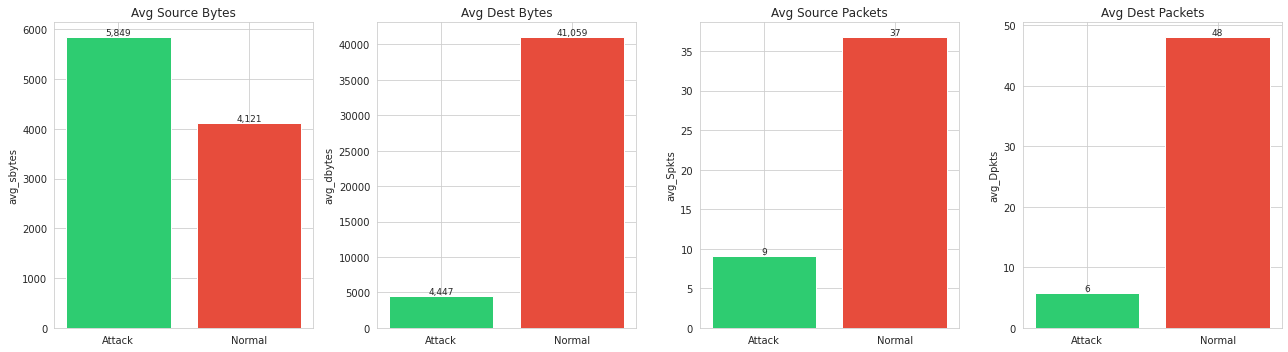

✅ Saved: 14_volume_analysis.png


In [22]:
# حجم البيانات المنقولة حسب Attack/Normal
volume_analysis = df.groupBy("Label").agg(
    avg("sbytes").alias("avg_sbytes"),
    avg("dbytes").alias("avg_dbytes"),
    avg("Spkts").alias("avg_Spkts"),
    avg("Dpkts").alias("avg_Dpkts"),
    avg("dur").alias("avg_dur")
).toPandas()

volume_analysis["Type"] = volume_analysis["Label"].map({0: "Normal", 1: "Attack"})
print("📊 Average Traffic Volume:")
print(volume_analysis)

# رسم
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = ["avg_sbytes", "avg_dbytes", "avg_Spkts", "avg_Dpkts"]
titles = ["Avg Source Bytes", "Avg Dest Bytes", "Avg Source Packets", "Avg Dest Packets"]
colors = ["#2ecc71", "#e74c3c"]

for ax, metric, title in zip(axes, metrics, titles):
    ax.bar(volume_analysis["Type"], volume_analysis[metric], color=colors)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(metric)
    for i, v in enumerate(volume_analysis[metric]):
        ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/14_volume_analysis.png", dpi=100)
plt.show()
print("✅ Saved: 14_volume_analysis.png")

In [ ]:
# =========================================================
# اختبار الاتصال بـ PostgreSQL
# =========================================================

PG_URL = "jdbc:postgresql://dockerfilespark-cluster_util_db-1:5432/postgres"
PG_USER = "postgres"
PG_PASSWORD = "itversity"

print(f"📌 URL: {PG_URL}")

try:
    test_df = spark.read \
        .format("jdbc") \
        .option("url", PG_URL) \
        .option("user", PG_USER) \
        .option("password", PG_PASSWORD) \
        .option("driver", "org.postgresql.Driver") \
        .option("query", "SELECT version()") \
        .load()
    
    test_df.show(truncate=False)
    print("✅ الاتصال ناجح!")
    
except Exception as e:
    print(f"❌ فشل: {e}")